In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PowerTransformer

from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv('concrete_data.csv')


In [6]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
758,350.0,0.0,0.0,203.0,0.0,974.0,775.0,14,22.53
301,290.4,0.0,96.2,168.1,9.4,961.2,865.0,28,34.74
662,157.0,236.0,0.0,192.0,0.0,935.4,781.2,28,33.66
669,288.0,192.0,0.0,192.0,0.0,932.0,717.8,3,16.11
39,237.5,237.5,0.0,228.0,0.0,932.0,594.0,180,36.25


In [7]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [9]:
# To check 0 value in data
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [15]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [16]:
y.head(2)

0    79.99
1    61.89
Name: Strength, dtype: float64

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
# Scaling the data

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
scaler.fit(X_train)

StandardScaler()

In [24]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# # Applying Regression without any transformation

In [28]:
lr = LinearRegression()

In [30]:
lr.fit(X_train_scaled,y_train)
lr.fit(X_test_scaled,y_test)

LinearRegression()

In [31]:
y_pred = lr.predict(X_test_scaled)

In [32]:
r2_score(y_test,y_pred)

0.6833032776365598

# # Cross checking with cross val score

In [33]:
lr = LinearRegression()

In [35]:
np.mean(cross_val_score(lr,X,y,scoring='r2'))

0.4609940491662864

# # Plotting the distplots without any transformation

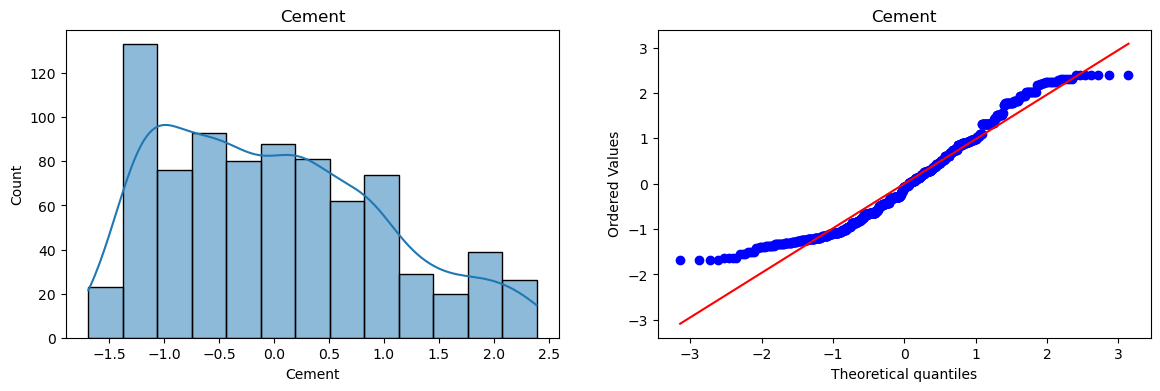

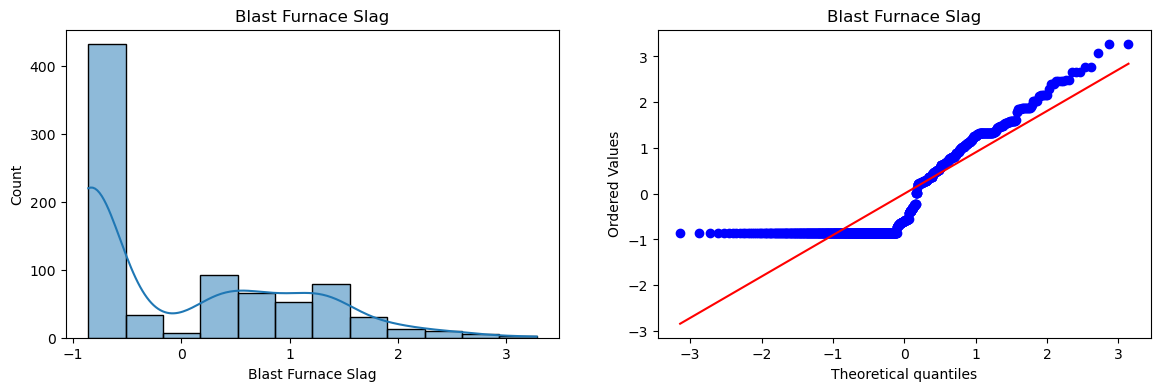

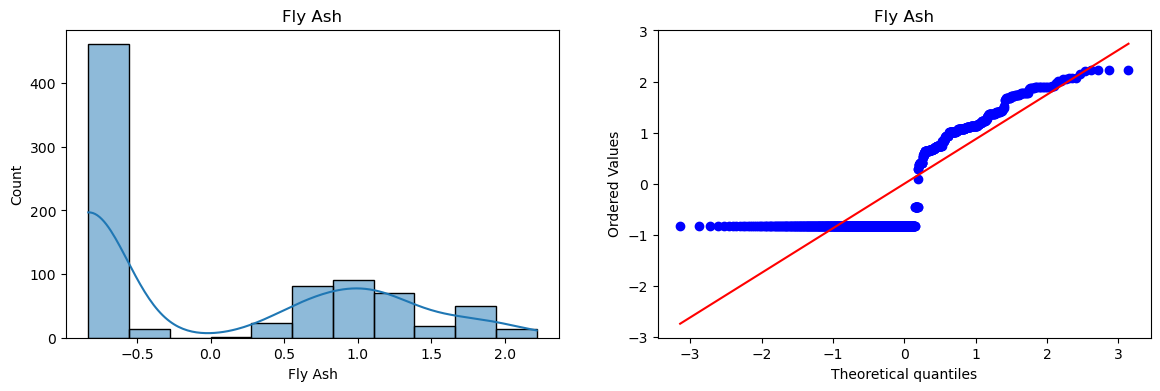

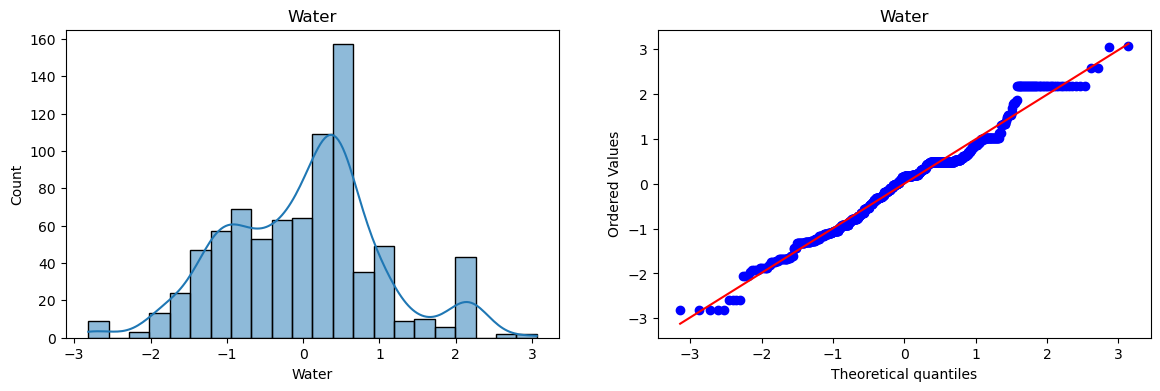

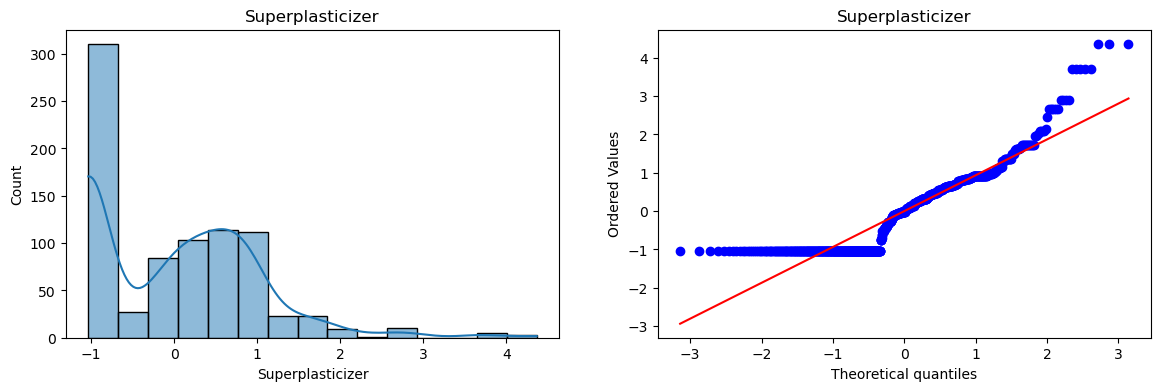

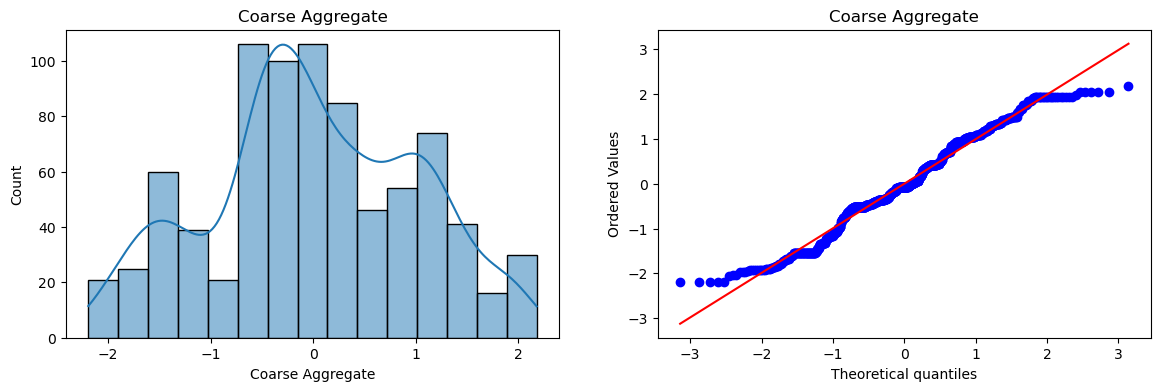

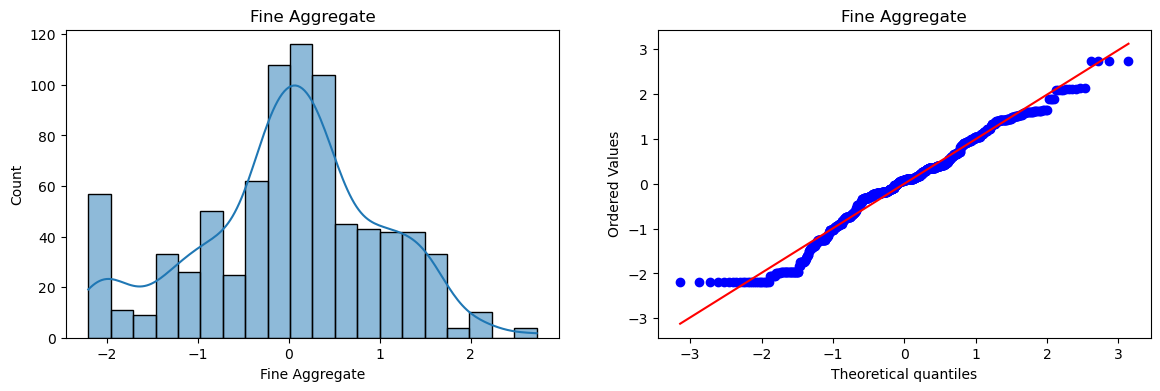

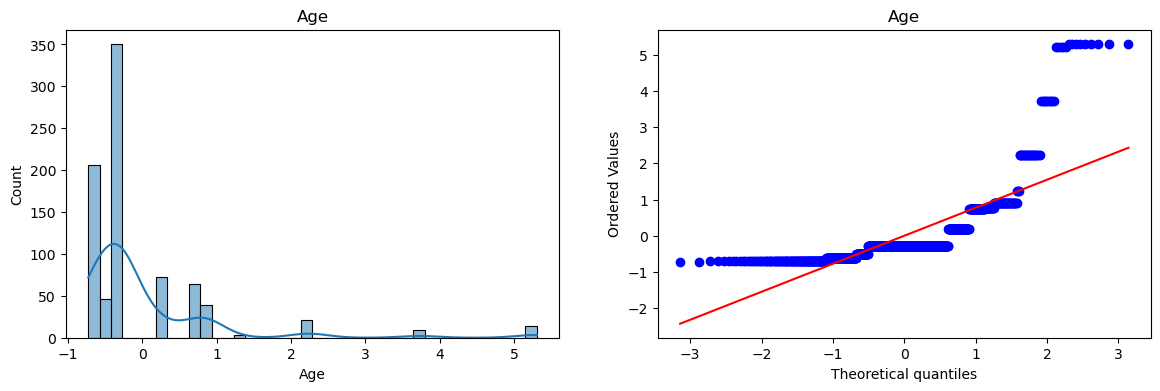

In [37]:
for col in X_train_scaled.columns:
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.histplot(X_train_scaled[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train_scaled[col], dist='norm',plot=plt)
    plt.title(col)

    plt.show()

# Applying Box-Cox Transformation

In [39]:
pt = PowerTransformer(method='box-cox')

In [44]:
# we are adding 0.00001 cause box-cox doesnot support 0 values.
X_train_trans = pt.fit_transform(X_train+0.0000001)
X_test_trans = pt.transform(X_test+0.0000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.022767
2,Fly Ash,-0.034635
3,Water,0.772682
4,Superplasticizer,0.087141
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [45]:
# Applying Linear Regression on transformed data

lr = LinearRegression()
lr.fit(X_train_trans,y_train)

y_pred = lr.predict(X_test_trans)

r2_score(y_test,y_pred)

0.8042534504678884

In [46]:
# Using cross value score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.000001)

lr = LinearRegression()

np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))


0.666295031974616

In [50]:
X_train_trans = pd.DataFrame(X_train_trans,columns=X_train.columns)

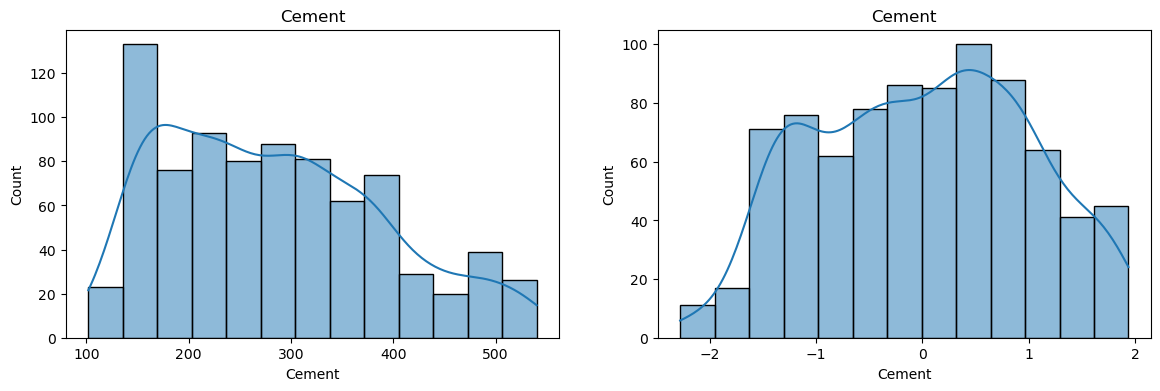

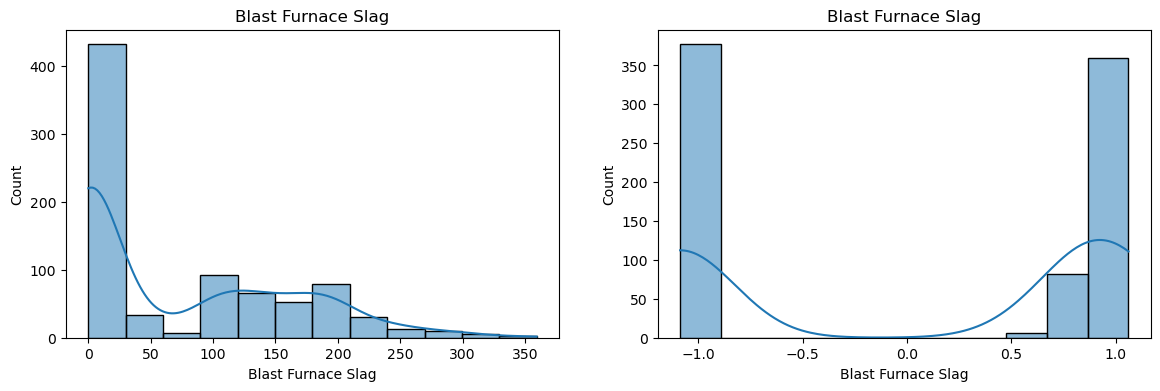

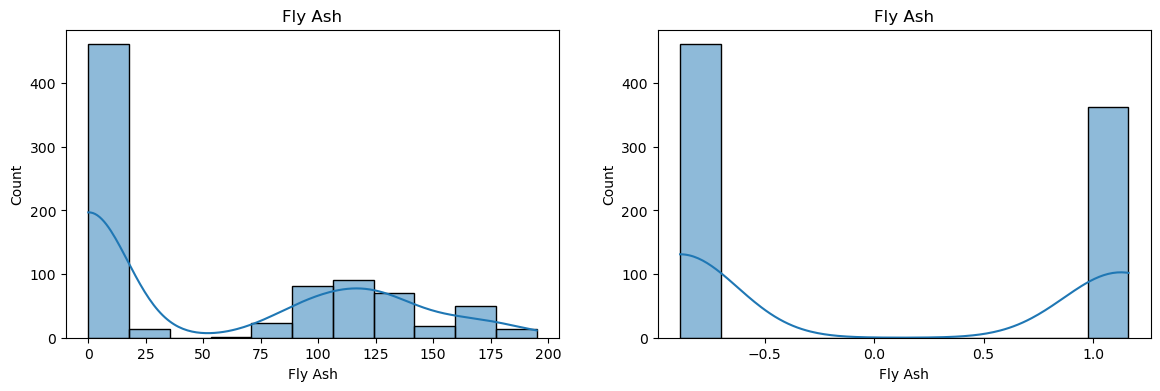

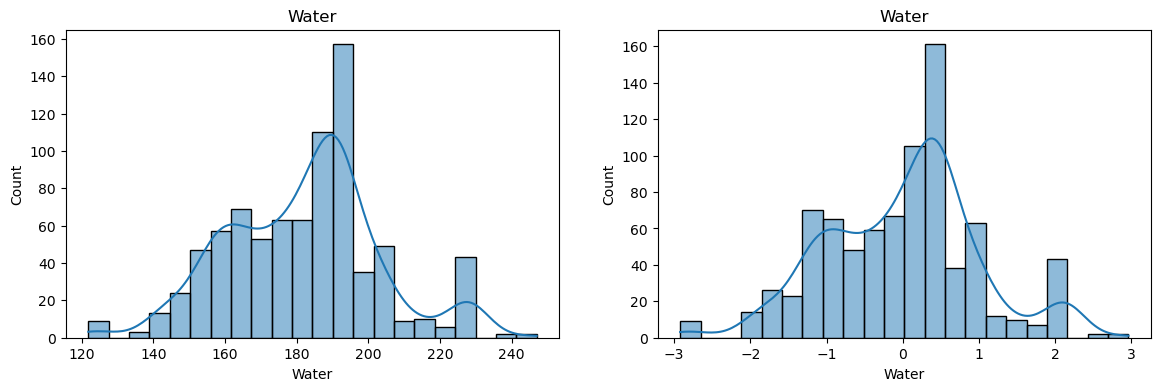

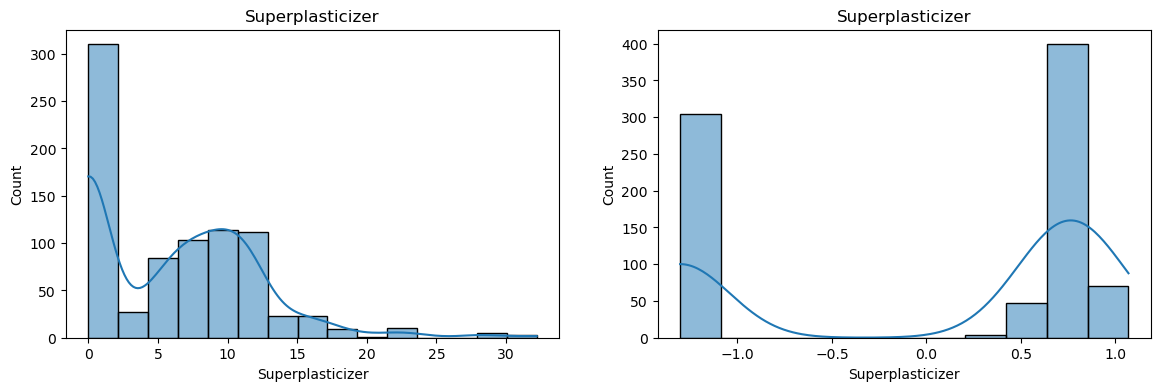

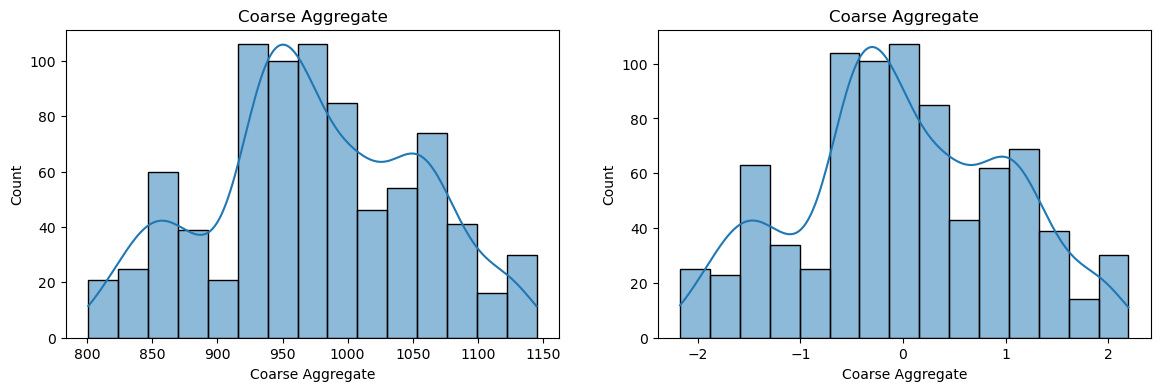

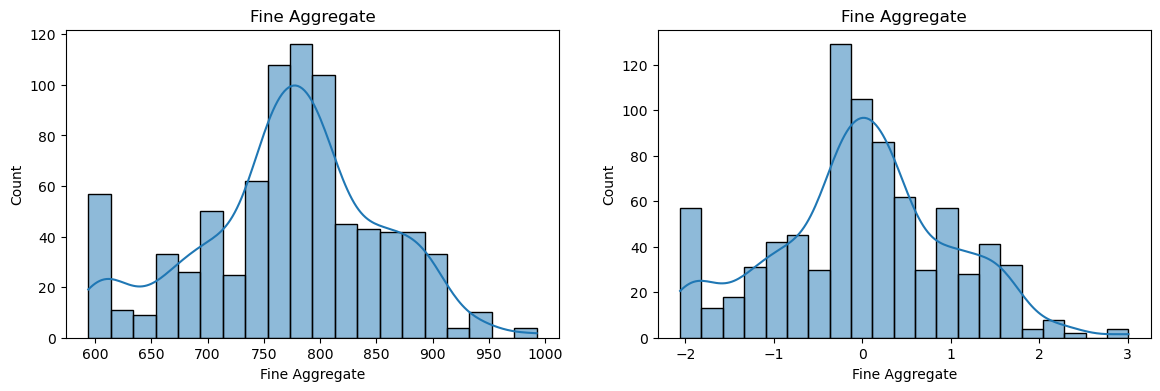

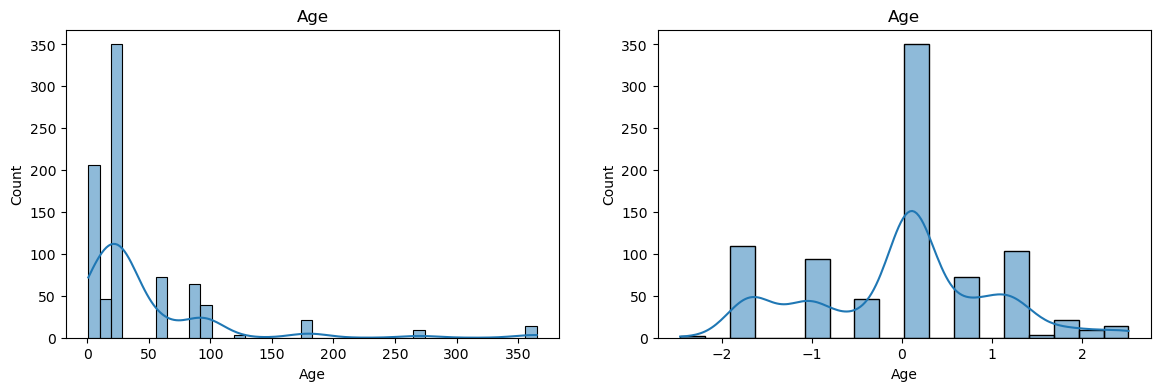

In [51]:
# Before and after comparision for Box-Cox Plot

for col in X_train_trans.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_trans[col],kde=True)
    plt.title(col)

    plt.show()

# Applying Yeo-Johnson transform

In [53]:
pt1 = PowerTransformer()

X_train_trans2 = pt1.fit_transform(X_train)
X_test_trans2 = pt1.transform(X_test)

lr = LinearRegression()

lr.fit(X_train_trans2,y_train)

y_pred2 = lr.predict(X_test_trans)

print(r2_score(y_test,y_pred2))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.812003432390866


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [54]:
# applying cross val score

pt1 = PowerTransformer()
X_trans2 = pt1.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_trans2,y,scoring='r2'))


0.6834625134285744

In [56]:
X_train_trans2 = pd.DataFrame(X_train_trans2,columns=X_train.columns)

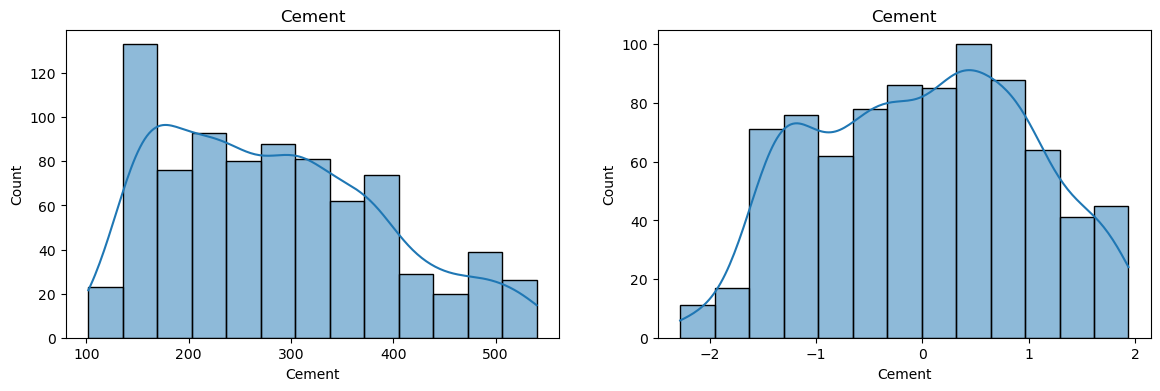

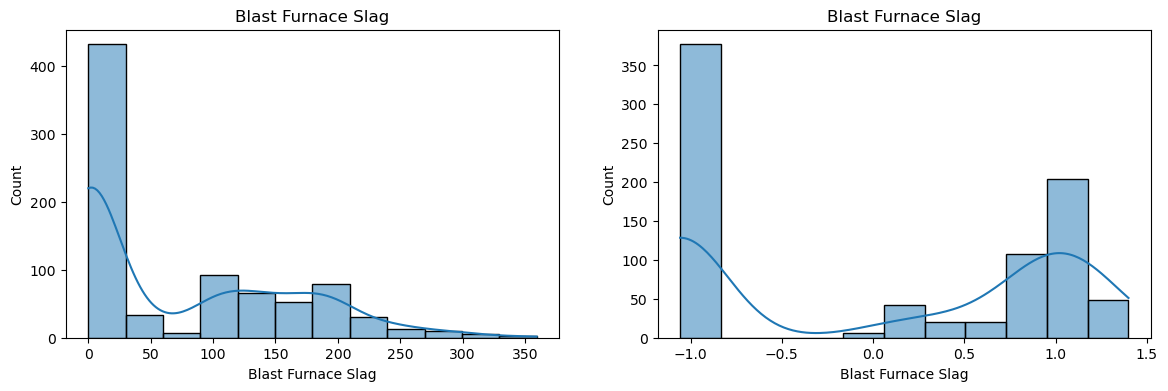

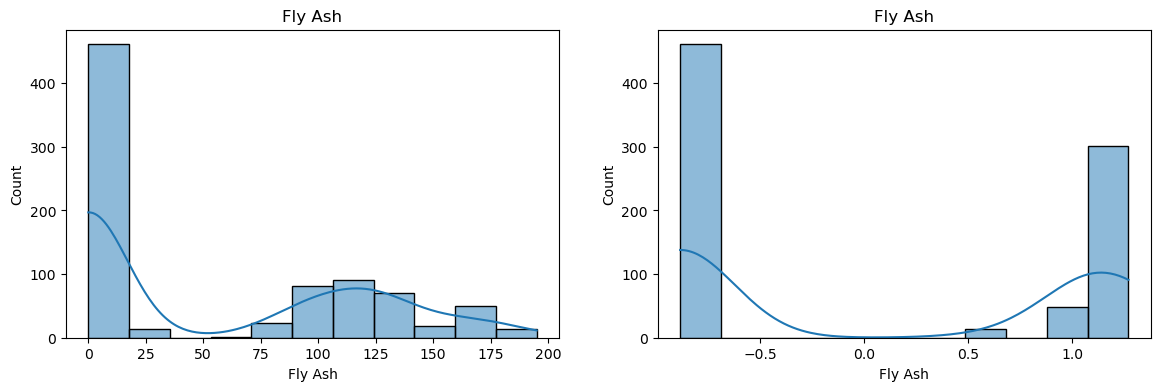

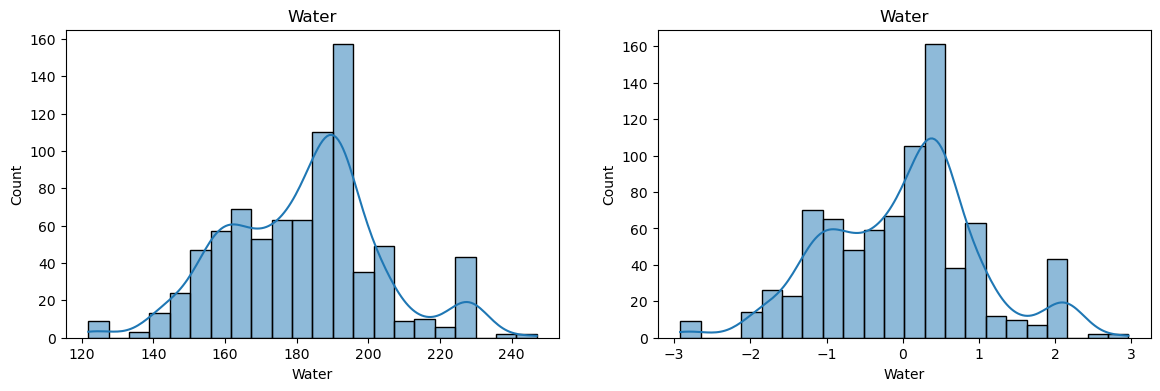

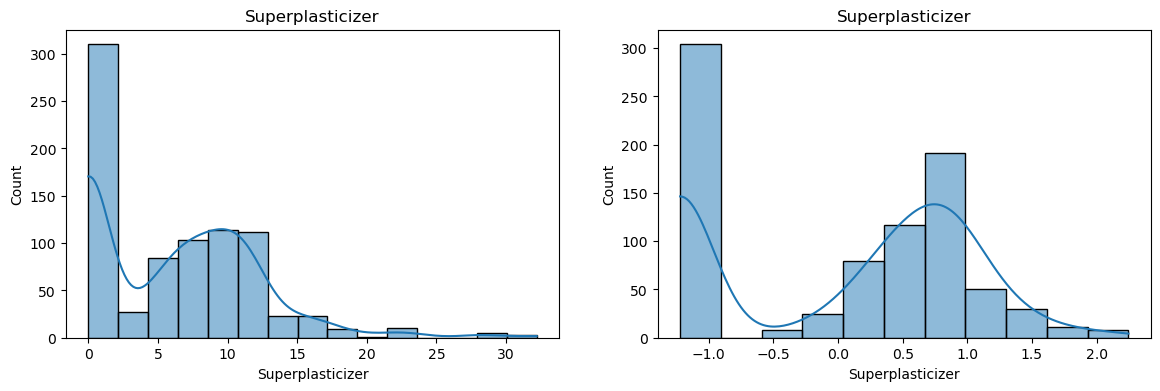

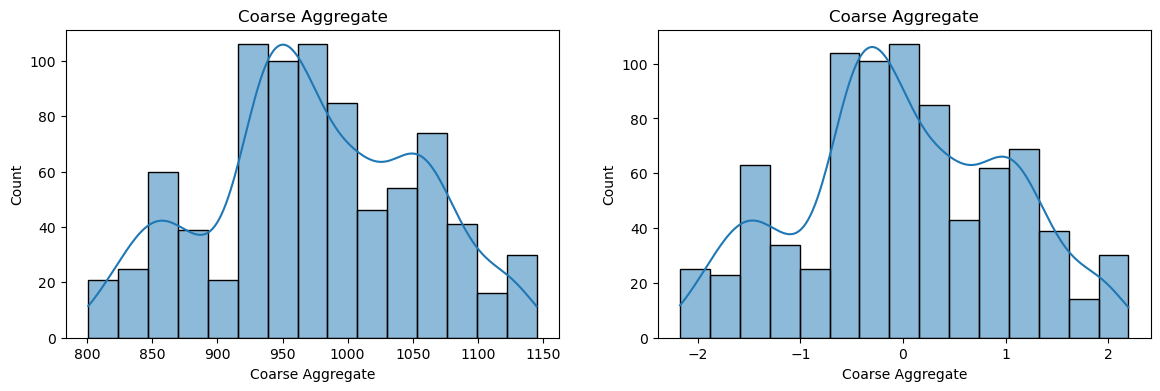

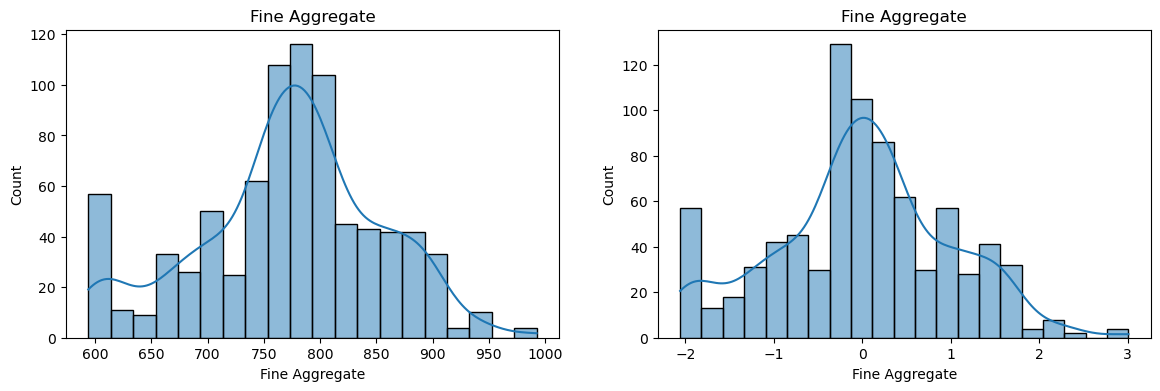

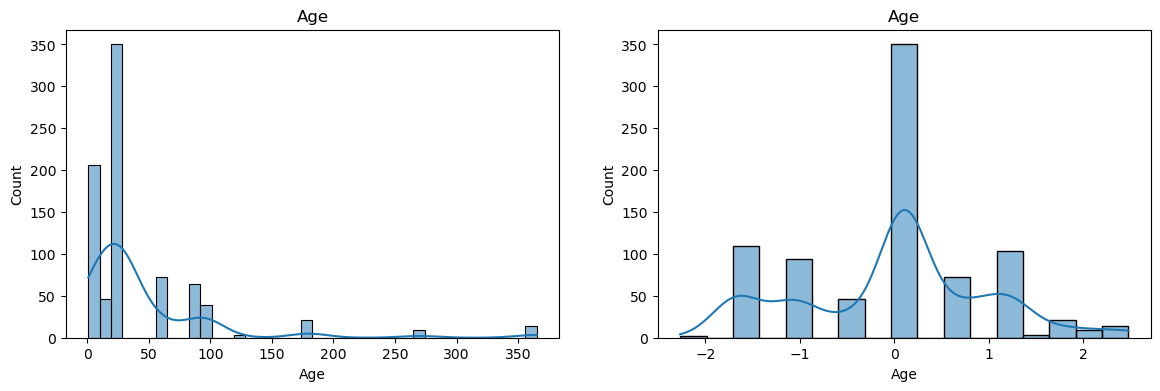

In [59]:
# Before and after comparision for Yeo-Johnson

for col in X_train_trans2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_trans2[col],kde=True)
    plt.title(col)

    plt.show()